In [ ]:
# %matplotlib inline
# !git clone https://github.com/alx87grd/minilink
# import sys
# sys.path.append('/content/minilink')

In [2]:
import numpy as np

from minilink.core.diagram import DiagramSystem
from minilink.core.system import DynamicSystem, StaticSystem

In [3]:
from minilink.control.pendulum_pd import PendulumPDController
from minilink.dynamics.catalog.pendulum.pendulum import Pendulum
from minilink.core.blocks.sources import Step, WhiteNoise

# Diagram Creation

## Subsystem definitions

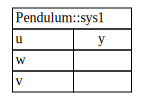

In [4]:
# Plant system
sys = Pendulum()
sys.params["m"] = 1.0
sys.params["l"] = 5.0
sys.x0[0] = 2.0

sys

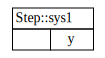

In [5]:
# Source input
step = Step()
step.params["initial_value"] = np.array([0.0])
step.params["final_value"] = np.array([1.0])
step.params["step_time"] = 10.0

step

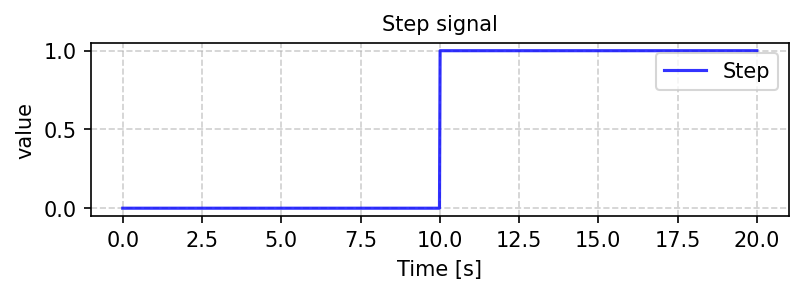

(<Figure size 900x225 with 1 Axes>,
 <Axes: title={'center': 'Step signal'}, xlabel='Time [s]', ylabel='value'>)

In [6]:
step.show_signal(t0=0.0, tf=20.0)

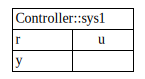

In [7]:
# Closed loop system
ctl = PendulumPDController()
ctl.params["Kp"] = 1000.0
ctl.params["Kd"] = 100.0
ctl

## Creating the diagram

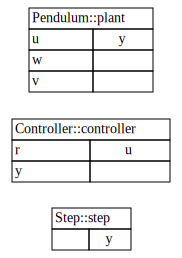

In [8]:
# Diagram
diagram = DiagramSystem()

diagram.add_subsystem(step, "step")
diagram.add_subsystem(ctl, "controller")
diagram.add_subsystem(sys, "plant")

diagram

Automatic dt based on the smallest time constant of the system
Compiling with backend='numpy'.
Simulator:
--------------
Simulating system Diagram from t=0 to t=20
Time steps = 200001, dt=0.0001 and solver= scipy


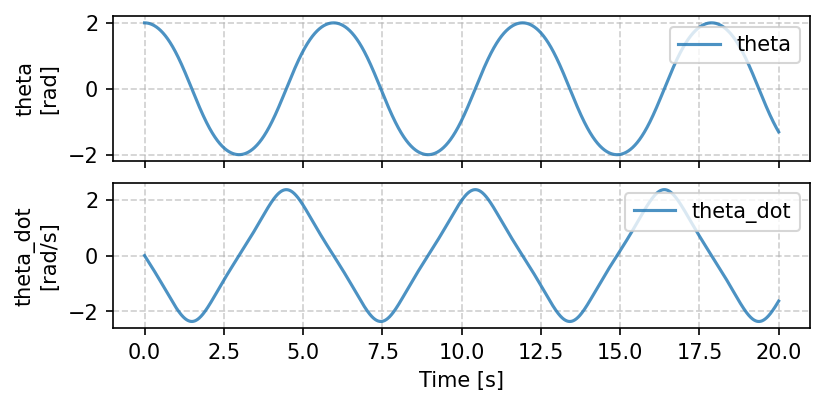

In [9]:
traj = diagram.compute_trajectory(tf=20, show=True)

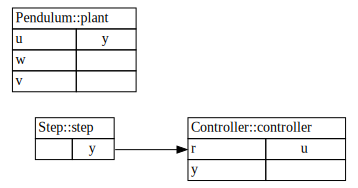

In [10]:
diagram.connect("step", "y", "controller", "r")
diagram

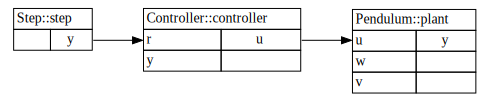

In [11]:
diagram.connect("controller", "u", "plant", "u")
diagram

In [12]:
diagram.compute_trajectory(tf=20)

Automatic dt based on the smallest time constant of the system
Compiling with backend='numpy'.
Simulator:
--------------
Simulating system Diagram from t=0 to t=20
Time steps = 200001, dt=0.0001 and solver= scipy


Trajectory(t=array([0.00000e+00, 1.00000e-04, 2.00000e-04, ..., 1.99998e+01,
       1.99999e+01, 2.00000e+01], shape=(200001,)), x=array([[ 2.00000000e+00,  1.99999999e+00,  1.99999996e+00, ...,
         2.02085871e+03,  2.02089887e+03,  2.02093904e+03],
       [ 0.00000000e+00, -1.78404155e-04, -3.56808312e-04, ...,
         4.01638951e+02,  4.01643103e+02,  4.01647256e+02]],
      shape=(2, 200001)), u=array([], shape=(0, 200001), dtype=float64), signals=mappingproxy({}))

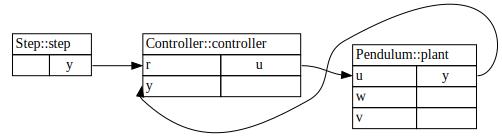

In [13]:
diagram.connect("plant", "y", "controller", "y")
diagram

In [14]:
diagram.compute_trajectory(tf=20)

Automatic dt based on the smallest time constant of the system
Compiling with backend='numpy'.
Simulator:
--------------
Simulating system Diagram from t=0 to t=20
Time steps = 200001, dt=0.0001 and solver= scipy


Trajectory(t=array([0.00000e+00, 1.00000e-04, 2.00000e-04, ..., 1.99998e+01,
       1.99999e+01, 2.00000e+01], shape=(200001,)), x=array([[ 2.00000000e+00,  1.99999959e+00,  1.99999836e+00, ...,
         9.59823593e-01,  9.59823593e-01,  9.59823593e-01],
       [ 0.00000000e+00, -8.17676816e-03, -1.63502631e-02, ...,
         1.08078885e-07,  1.08131522e-07,  1.08184107e-07]],
      shape=(2, 200001)), u=array([], shape=(0, 200001), dtype=float64), signals=mappingproxy({}))

# Custom sys

In [15]:
class Integrator(DynamicSystem):
    def __init__(self):

        super().__init__(n=1, input_dim=1, output_dim=1, y_dependencies=())
        self.name = "Integrator"

    def f(self, x, u, t=0, params=None):

        dx = np.zeros(self.n)
        dx[0] = u[0]

        return dx

    def h(self, x, u, t=0, params=None):

        y = np.zeros(self.p)
        y[0] = x[0]

        return y

In [16]:
class PropController(StaticSystem):
    def __init__(self):
        super().__init__()

        self.params = {
            "Kp": 10.0,
        }

        self.name = "Controller"

        self.add_input_port("r", nominal_value=0.0)
        self.add_input_port("y", nominal_value=0.0)

        self.add_output_port("u", function=self.ctl, dependencies=("r", "y"))

    ######################################################################
    def ctl(self, x, u, t=0, params=None):

        if params is None:
            params = self.params

        Kp = params["Kp"]

        r = u[0]
        y = u[1]

        u = Kp * (r - y)

        u = np.array([u])

        return u

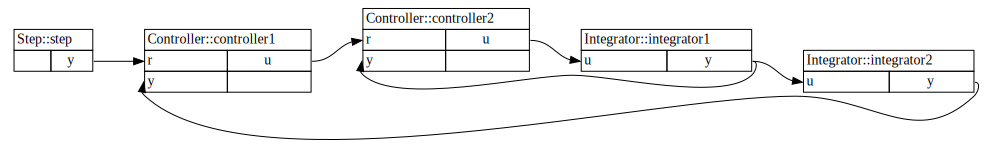

In [17]:
## Cascade controller diagram

# Plant system
sys1 = Integrator()
sys1.state.labels = ["v"]
sys1.x0[0] = 20.0
sys2 = Integrator()
sys2.state.labels = ["x"]
sys2.x0[0] = 20.0

# Controllers
ctl1 = PropController()
ctl1.params["Kp"] = 1.0
ctl2 = PropController()
ctl2.params["Kp"] = 1.0

# Source input
step = Step()
step.params["initial_value"] = np.array([0.0])
step.params["final_value"] = np.array([1.0])
step.params["step_time"] = 10.0

# # Diagram
diagram = DiagramSystem()

diagram.add_subsystem(step, "step")
diagram.add_subsystem(ctl1, "controller1")
diagram.add_subsystem(ctl2, "controller2")
diagram.add_subsystem(sys1, "integrator1")
diagram.add_subsystem(sys2, "integrator2")

diagram.connect("integrator1", "y", "integrator2", "u")
diagram.connect("controller2", "u", "integrator1", "u")
diagram.connect("integrator1", "y", "controller2", "y")
diagram.connect("controller1", "u", "controller2", "r")
diagram.connect("integrator2", "y", "controller1", "y")
diagram.connect("step", "y", "controller1", "r")
diagram

In [ ]:
traj = diagram.compute_trajectory()

# Noise ports exemple

In [ ]:
# Plant system
sys = Pendulum()

sys.params["m"] = 1.0
sys.params["l"] = 5.0

sys.x0[0] = 2.0

# Source input
step = Step()
step.params["initial_value"] = np.array([0.0])
step.params["final_value"] = np.array([1.0])
step.params["step_time"] = 10.0

# Noisy input
noise = WhiteNoise(1)
noise.params["var"] = 1.0
noise.params["mean"] = 0.0
noise.params["seed"] = 1

# Noisy measurement
noise2 = WhiteNoise(1)
noise2.params["var"] = 0.1
noise2.params["mean"] = 0.0
noise2.params["seed"] = 2

# Closed loop system
ctl = PendulumPDController()
ctl.params["Kp"] = 1000.0
ctl.params["Kd"] = 100.0

# Diagram
diagram2 = DiagramSystem()

diagram2.add_subsystem(step, "step")
diagram2.add_subsystem(ctl, "controller")
diagram2.add_subsystem(sys, "plant")
diagram2.add_subsystem(noise, "noise")
diagram2.add_subsystem(noise2, "noise2")

diagram2.connect("step", "y", "controller", "r")
diagram2.connect("controller", "u", "plant", "u")
diagram2.connect("plant", "y", "controller", "y")
diagram2.connect("noise", "y", "plant", "w")
diagram2.connect("noise2", "y", "plant", "v")
diagram2

In [ ]:
noise2.show_signal(t0=-300.0, tf=300.0)

In [ ]:
noise2.params

In [ ]:
diagram2.compute_trajectory(
    solver="euler", dt=0.01
)  # White noise is not a continuous system.. and scipy does not like it..

In [ ]:
traj = diagram2.compute_trajectory(show=False) 

In [ ]:
diagram2.subsystems["noise"].params["var"] = 0.001
diagram2.subsystems["noise2"].params["var"] = 0.001
diagram2.compute_trajectory(solver="euler", dt=0.01)

In [ ]:
diagram2.subsystems["noise"].params["var"] = 10.0
diagram2.subsystems["noise2"].params["var"] = 10.0
diagram2.compute_trajectory(solver="euler", dt=0.01)

# Animation tools

In [ ]:
# Plant system
sys = Pendulum()

sys.params["m"] = 1.0
sys.params["l"] = 5.0

sys.x0[0] = 2.0
sys.compute_trajectory(tf=20.0, dt=0.01, show=False)

In [ ]:
sys.animate()

In [ ]:
sys.animate(renderer="pygame")

In [ ]:
sys.animate(renderer="meshcat")

In [ ]:
sys.animate(renderer="matplotlib", html=True)

# Interactive mode

In [ ]:
# Plant system
sys = Pendulum()

sys.params["m"] = 1.0
sys.params["l"] = 5.0

In [ ]:
sys.game(renderer="meshcat")

In [ ]:
sys.game(renderer="pygame")

In [ ]:
from minilink.dynamics.catalog.vehicles.dynamic_bicycle import DynamicBicycleCar3D

sys = DynamicBicycleCar3D()
sys.game(renderer="meshcat")


# Compilation to jax

In [ ]:
import time

import numpy as np

from minilink.core.diagram import DiagramSystem
from minilink.core.system import System

try:
    import jax.numpy as jnp

    JAX_AVAILABLE = True
except ImportError:
    JAX_AVAILABLE = False


class SimpleGain(System):
    def __init__(self, id_str, gain=2.0):
        super().__init__(0)
        self.name = id_str
        self.gain = gain
        self.add_input_port("u")
        self.add_output_port("y", function=self.h, dependencies=("u",))

    def h(self, x, u, t=0, params=None):
        return u * self.gain


class SimpleIntegrator(System):
    def __init__(self, id_str):
        super().__init__(1)
        self.name = id_str
        self.add_input_port("u")
        self.add_output_port("x", function=self.compute_state, dependencies=())

    def compute_state(self, x, u, t=0, params=None):
        return x

    def f(self, x, u, t=0, params=None):
        return u * u * u

In [ ]:
sys = SimpleIntegrator('aaa')
sys.f(11,2,0)


In [ ]:
eval = sys.compile(backend="jax")
eval.f

In [ ]:
class MultiInputNode(System):
    def __init__(self, id_str, in_ports):
        super().__init__(1)
        self.name = id_str
        self.in_ports = in_ports
        for p in range(in_ports):
            self.add_input_port(f"u{p}")
        self.add_output_port("x", function=self.compute_state, dependencies="all")

    def compute_state(self, x, u, t=0, params=None):
        return x

    def f(self, x, u, t=0, params=None):
        return u.sum()


def build_dense_network(num_nodes=50, connections_per_node=3):
    """Builds a dense feed-forward network of nodes."""
    diag = DiagramSystem()
    diag.connection_verbose = False
    for i in range(num_nodes):
        diag.add_subsystem(SimpleIntegrator(f"Integrator{i}"), f"Node{i}")

    np.random.seed(42)
    for i in range(1, num_nodes):
        num_conn = min(i, connections_per_node)
        sources = np.random.choice(range(i), size=num_conn, replace=False)

        sys_id = f"MultiNode{i}"
        diag.add_subsystem(MultiInputNode(sys_id, num_conn), sys_id)

        for p_idx, src_i in enumerate(sources):
            diag.connect(f"Node{src_i}", "x", sys_id, f"u{p_idx}")

        diag.connect(sys_id, "x", f"Node{i}", "u")

    diag.add_subsystem(SimpleGain("SourceNode"), "SourceNode")
    diag.connect("SourceNode", "y", "Node0", "u")
    return diag


In [ ]:
diag = build_dense_network(num_nodes=10, connections_per_node=10)
diag
# diag.plot_diagram()

In [ ]:
diag.n

In [ ]:
# diag.compute_trajectory(tf=20.0)
PRINT_COMPILE_REPORT = True  # Print compile timing diagnostics.
np_eval = diag.compile(backend="numpy", verbose=PRINT_COMPILE_REPORT)


In [ ]:
eval_jax = diag.compile(backend="jax", verbose=PRINT_COMPILE_REPORT)

In [ ]:

n_iters = 1000
print(f"\nBenchmarking {n_iters} iterations:")

f_python = diag.f
f_numpy = np_eval.f
f_jax = eval_jax.f

x = np.random.randn(diag.n)
u = np.random.randn(diag.m)

# Baseline (recursive)
t0 = time.perf_counter()
for _ in range(n_iters):
    f_python(x, u)
dt = time.perf_counter() - t0
print(f"Baseline:       {dt:.4f} s ({n_iters/dt:.0f} evals/sec)")

# NumPy Compiled
t0 = time.perf_counter()
for _ in range(n_iters):
    f_numpy(x, u)
dt = time.perf_counter() - t0
print(f"NumPy Compiled: {dt:.4f} s ({n_iters/dt:.0f} evals/sec)")



t0 = time.perf_counter()
for _ in range(n_iters):
    f_jax(x, u).block_until_ready()
dt = time.perf_counter() - t0
print(f"JAX JIT:        {dt:.4f} s ({n_iters/dt:.0f} evals/sec)")


# Symbolic

In [ ]:
from minilink.symbolic.mechanics.model import MechanicalModel

# ------------------------------------------------------------------
# Build the symbolic model
# ------------------------------------------------------------------
m = MechanicalModel("QuadruplePendulum")
N_LINKS = 4

lengths, com_offsets, masses, inertias = [], [], [], []
for i in range(1, N_LINKS + 1):
    li, lci = m.parameters(f"l{i} lc{i}")
    mi = m.parameters(f"m{i}")
    Ii = m.parameters(f"I{i}")
    lengths.append(li)
    com_offsets.append(lci)
    masses.append(mi)
    inertias.append(Ii)

g_sym = m.parameters("g")

coord_names = " ".join(f"q{i}" for i in range(1, N_LINKS + 1))
coords = m.coordinates(coord_names)

dh_table = [
    {"theta": coords[i], "d": 0, "a": lengths[i], "alpha": 0} for i in range(N_LINKS)
]
link_properties = [
    {
        "mass": masses[i],
        "inertia": {"Izz": inertias[i]},
        "com_offset": com_offsets[i],
    }
    for i in range(N_LINKS)
]

m.add_dh_chain(dh_table, link_properties)
m.add_gravity(-g_sym * m.N.y)

# ------------------------------------------------------------------
# Derive the symbolic equations of motion
# -----------------------------------------------------------------
print("Deriving the symbolic equations of motion...")

sym_sys = m.derive(method="lagrange", simplify=True)

In [ ]:
sym_sys.H

In [ ]:
sym_sys.g

### exporting to minlink  sys

In [ ]:
params = {}
for i in range(N_LINKS):
    params[lengths[i]] = 1.5
    params[com_offsets[i]] = 1.5
    params[masses[i]] = 10.0
    params[inertias[i]] = 0.1
params[g_sym] = 9.81

sys = sym_sys.to_minilink(parameters=params, backend="jax")

sys

In [ ]:
sys.compute_trajectory(tf=10.0)

In [ ]:
# sys.animate(renderer="pygame")
sys.animate(renderer="meshcat")

# Engine

In [ ]:
from minilink.physics.system import PhysicsWorldSystem
from minilink.physics.engine_jax import PlaneModel, SphereModel, make_world_model

# 10x larger scene than the 12-sphere MVP: 12x10 grid = 120 spheres.
nx, ny = 12, 10
n_spheres = nx * ny

# Smooth radius/mass variation for visual diversity.
radii = np.linspace(0.18, 0.35, n_spheres)
masses = np.linspace(0.6, 1.8, n_spheres)
specs = list(zip(radii, masses))
spheres = [SphereModel(mass=m, radius=r) for (r, m) in specs]

# XY layout and varied Z heights.
x_vals = np.linspace(-6.0, 6.0, nx)
y_vals = np.linspace(-4.5, 4.5, ny)
xy_grid = [(x, y) for y in y_vals for x in x_vals]
z_heights = np.linspace(1.0, 6.0, n_spheres)

world = make_world_model(
    spheres,
    PlaneModel(normal=(0.0, 0.0, 1.0), offset=0.0),
    gravity=(0.0, 0.0, -9.81),
    k_contact=1000.0,
    c_contact=1.0,
)

In [ ]:
sys = PhysicsWorldSystem(world, name="PhysicsManySpheres")

# State layout per body: [p(3), q(4), v(3), w(3)].
x0 = np.zeros(sys.n)
for i in range(sys.world.n_bodies):
    base = 13 * i
    x, y = xy_grid[i]
    z = z_heights[i]
    x0[base : base + 3] = [x, y, z]
    x0[base + 3 : base + 7] = [1.0, 0.0, 0.0, 0.0]  # unit quaternion
sys.x0 = x0

sys


In [ ]:
sys.compute_trajectory(tf=10.0, show=False, solver="rk4_fixedsteps", compile_backend="jax")
sys.animate(renderer="meshcat")

### Engine is jax compatible

In [ ]:
x = np.random.randn(sys.n)
u = np.random.randn(sys.m)

evaluator = sys.compile(backend="jax", verbose=PRINT_COMPILE_REPORT)

n_iter = 1000
t0 = time.perf_counter()
for _ in range(n_iter):
    sys.f(x, u, 0.0)
t_pure = time.perf_counter() - t0

t0 = time.perf_counter()
for _ in range(n_iter):
    evaluator.f(x, u, 0.0)
t_compiled = time.perf_counter() - t0

print(
    f"Speed ({n_iter} calls): \n"
    f"sys.f (native python):   {1e6 * t_pure / n_iter:.1f} us/call,\n"
    f"evaluator.f (jax jit):   {1e6 * t_compiled / n_iter:.1f} us/call, "
)


### Not only faster but auto-diff compatible

In [ ]:
import jax
u = np.zeros(sys.m)
t=0.0

fx = lambda x: evaluator.f(x, u, t)

df_dx_func = jax.jacfwd(fx)

x = np.random.randn(sys.n)
df_dx = df_dx_func(x)

df_dx





## ODE solvers

In [ ]:
from minilink.simulation.benchmark import (
    DEFAULT_SIMULATION_VARIANTS,
    benchmark_simulation_matrix,
    print_simulation_matrix_benchmark,
)

In [ ]:
res = benchmark_simulation_matrix(
    sys,
    case_name="PhysicsManySpheres (24 bodies)",
    variants=DEFAULT_SIMULATION_VARIANTS,
    t0=0.0,
    tf=0.5,
    dt=0.01,
    n_runs=1,
)

In [ ]:
print_simulation_matrix_benchmark(res)